<a href="https://colab.research.google.com/github/salianvikram/VTU-MAJOR-PROJECT-27/blob/main/GB_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries imported successfully.


/tmp/ipykernel_3228/2397422826.py:41: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FILE_NAME)



Dataset loaded successfully.
Dataset shape: (1048575, 16)

Available columns:
['StationId', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Required columns found.

Datetime conversion completed.

Data sorted chronologically.

Pollutant features:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

Numeric conversion completed.

Time features created.

Cyclic time features created.

Creating pollutant lag features...
Pollutant lag features created.

Creating AQI lag features...
AQI lag features created.

Creating rolling pollutant features...


/tmp/ipykernel_3228/2397422826.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_rolling_3'] = (
/tmp/ipykernel_3228/2397422826.py:311: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_rolling_6'] = (
/tmp/ipykernel_3228/2397422826.py:326: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.co

Rolling pollutant features created.

Creating rolling AQI features...


/tmp/ipykernel_3228/2397422826.py:350: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AQI_rolling_3'] = (
/tmp/ipykernel_3228/2397422826.py:368: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AQI_rolling_6'] = (
/tmp/ipykernel_3228/2397422826.py:386: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


Rolling AQI features created.

Next-hour AQI target created.

Total features: 130

Removing missing values...
Rows available for modelling: 28378
Rows after cleaning: 28378

Feature datatype conversion completed.


TRAIN / TEST SPLIT
Training rows: 19157
Testing rows: 9221

Training shape:
(19157, 130)

Testing shape:
(9221, 130)


TRAINING GRADIENT BOOSTING MODEL...

Gradient Boosting training completed.

Generating predictions...
Predictions generated.


GRADIENT BOOSTING MODEL PERFORMANCE
MAE  : 3.88
MSE  : 50.50
RMSE : 7.11
R²   : 0.9919


MODEL INFORMATION
Algorithm       : HistGradientBoostingRegressor
Boosting rounds : 300
Learning rate   : 0.05
Training rows   : 19157
Testing rows    : 9221
Features        : 130


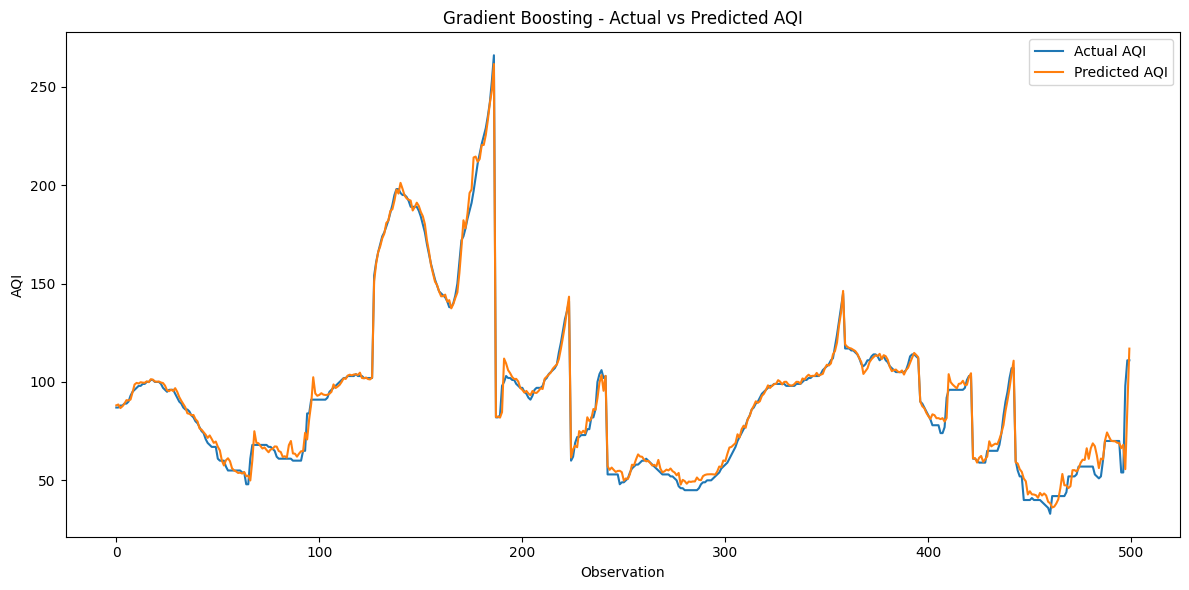

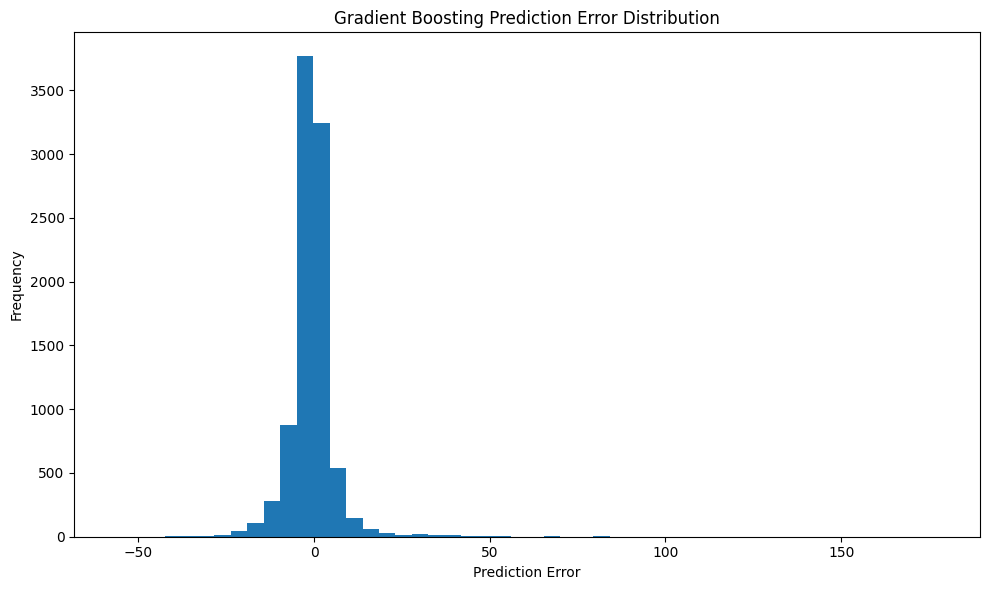


Model saved successfully:
AQI_GradientBoosting_Model3.pkl

Feature list saved successfully.


FINAL GRADIENT BOOSTING MODEL 3 SUMMARY
Algorithm        : Gradient Boosting
Implementation    : Histogram Gradient Boosting
Prediction        : Next-Hour AQI
Pollutants        : All available pollutants
Lag periods       : 1, 3, 6, 12, 24
Rolling periods   : 3, 6, 24
Training period   : 2015 - 2019
Testing period    : 2020
MAE               : 3.88
RMSE              : 7.11
R²                : 0.9919


In [8]:
# ============================================================
# AQI PREDICTION USING GRADIENT BOOSTING
# MODEL 3
#
# ALL POLLUTANTS
# + TIME FEATURES
# + LAG FEATURES
# + ROLLING FEATURES
# + NEXT-HOUR AQI FORECASTING
#
# LARGE DATASET OPTIMIZED VERSION
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")


# ============================================================
# 2. LOAD DATASET
# ============================================================

FILE_NAME = "station_hour.csv"

df = pd.read_csv(FILE_NAME)

print("\nDataset loaded successfully.")

print("Dataset shape:", df.shape)


# ============================================================
# 3. CLEAN COLUMN NAMES
# ============================================================

df.columns = df.columns.str.strip()

print("\nAvailable columns:")

print(df.columns.tolist())


# ============================================================
# 4. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [
    'StationId',
    'Datetime',
    'AQI'
]

missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]

if len(missing_columns) > 0:

    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("\nRequired columns found.")


# ============================================================
# 5. CONVERT DATETIME
# ============================================================

df['Datetime'] = pd.to_datetime(
    df['Datetime'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

# Remove invalid datetime rows

df = df.dropna(
    subset=['Datetime']
)

print("\nDatetime conversion completed.")


# ============================================================
# 6. SORT DATA
# ============================================================

df = df.sort_values(
    by=['StationId', 'Datetime']
).reset_index(drop=True)

print("\nData sorted chronologically.")


# ============================================================
# 7. DEFINE POLLUTANT FEATURES
# ============================================================

pollutant_features = [
    'PM2.5',
    'PM10',
    'NO',
    'NO2',
    'NOx',
    'NH3',
    'CO',
    'SO2',
    'O3',
    'Benzene',
    'Toluene',
    'Xylene'
]


# Keep only columns that exist

pollutant_features = [
    col
    for col in pollutant_features
    if col in df.columns
]


print("\nPollutant features:")

print(pollutant_features)


# ============================================================
# 8. CONVERT POLLUTANTS TO NUMERIC
# ============================================================

for col in pollutant_features:

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )


# Convert AQI

df['AQI'] = pd.to_numeric(
    df['AQI'],
    errors='coerce'
)


print("\nNumeric conversion completed.")


# ============================================================
# 9. CREATE TIME FEATURES
# ============================================================

df['Hour'] = df['Datetime'].dt.hour

df['Day'] = df['Datetime'].dt.day

df['Month'] = df['Datetime'].dt.month

df['DayOfWeek'] = df['Datetime'].dt.dayofweek

df['DayOfYear'] = df['Datetime'].dt.dayofyear

df['WeekOfYear'] = (
    df['Datetime']
    .dt.isocalendar()
    .week
    .astype(int)
)

df['Year'] = df['Datetime'].dt.year

df['IsWeekend'] = (
    df['DayOfWeek'] >= 5
).astype(int)


print("\nTime features created.")


# ============================================================
# 10. CREATE CYCLIC TIME FEATURES
# ============================================================

df['Hour_Sin'] = np.sin(
    2 * np.pi * df['Hour'] / 24
)

df['Hour_Cos'] = np.cos(
    2 * np.pi * df['Hour'] / 24
)

df['Month_Sin'] = np.sin(
    2 * np.pi * df['Month'] / 12
)

df['Month_Cos'] = np.cos(
    2 * np.pi * df['Month'] / 12
)

df['DayOfWeek_Sin'] = np.sin(
    2 * np.pi * df['DayOfWeek'] / 7
)

df['DayOfWeek_Cos'] = np.cos(
    2 * np.pi * df['DayOfWeek'] / 7
)


print("\nCyclic time features created.")


# ============================================================
# 11. CREATE POLLUTANT LAG FEATURES
# ============================================================

lag_hours = [1, 3, 6, 12, 24]

print("\nCreating pollutant lag features...")


for col in pollutant_features:

    grouped = df.groupby(
        'StationId'
    )[col]

    for lag in lag_hours:

        df[f'{col}_lag_{lag}'] = (
            grouped.shift(lag)
        )


print("Pollutant lag features created.")


# ============================================================
# 12. CREATE AQI LAG FEATURES
# ============================================================

print("\nCreating AQI lag features...")


aqi_grouped = df.groupby(
    'StationId'
)['AQI']


for lag in lag_hours:

    df[f'AQI_lag_{lag}'] = (
        aqi_grouped.shift(lag)
    )


print("AQI lag features created.")


# ============================================================
# 13. CREATE ROLLING POLLUTANT FEATURES
# ============================================================

print("\nCreating rolling pollutant features...")


for col in pollutant_features:

    grouped = df.groupby(
        'StationId'
    )[col]

    # Previous 3 observations

    df[f'{col}_rolling_3'] = (
        grouped
        .transform(
            lambda x:
            x.shift(1)
            .rolling(
                window=3,
                min_periods=3
            )
            .mean()
        )
    )

    # Previous 6 observations

    df[f'{col}_rolling_6'] = (
        grouped
        .transform(
            lambda x:
            x.shift(1)
            .rolling(
                window=6,
                min_periods=6
            )
            .mean()
        )
    )

    # Previous 24 observations

    df[f'{col}_rolling_24'] = (
        grouped
        .transform(
            lambda x:
            x.shift(1)
            .rolling(
                window=24,
                min_periods=24
            )
            .mean()
        )
    )


print("Rolling pollutant features created.")


# ============================================================
# 14. CREATE ROLLING AQI FEATURES
# ============================================================

print("\nCreating rolling AQI features...")


df['AQI_rolling_3'] = (

    df.groupby('StationId')['AQI']

    .transform(

        lambda x:
        x.shift(1)
        .rolling(
            window=3,
            min_periods=3
        )
        .mean()

    )
)


df['AQI_rolling_6'] = (

    df.groupby('StationId')['AQI']

    .transform(

        lambda x:
        x.shift(1)
        .rolling(
            window=6,
            min_periods=6
        )
        .mean()

    )
)


df['AQI_rolling_24'] = (

    df.groupby('StationId')['AQI']

    .transform(

        lambda x:
        x.shift(1)
        .rolling(
            window=24,
            min_periods=24
        )
        .mean()

    )
)


print("Rolling AQI features created.")


# ============================================================
# 15. CREATE NEXT-HOUR AQI TARGET
# ============================================================

# Current observation = t
#
# Target = AQI at t + 1


df['AQI_Next_Hour'] = (

    df.groupby('StationId')['AQI']
    .shift(-1)

)


print("\nNext-hour AQI target created.")


# ============================================================
# 16. DEFINE TIME FEATURE LIST
# ============================================================

time_features = [

    'Hour',
    'Day',
    'Month',
    'DayOfWeek',
    'DayOfYear',
    'WeekOfYear',
    'Year',
    'IsWeekend',

    'Hour_Sin',
    'Hour_Cos',

    'Month_Sin',
    'Month_Cos',

    'DayOfWeek_Sin',
    'DayOfWeek_Cos'

]


# ============================================================
# 17. DEFINE LAG FEATURE LIST
# ============================================================

lag_features = []


for col in pollutant_features:

    for lag in lag_hours:

        lag_features.append(
            f'{col}_lag_{lag}'
        )


# ============================================================
# 18. DEFINE AQI LAG FEATURE LIST
# ============================================================

aqi_lag_features = [

    f'AQI_lag_{lag}'

    for lag in lag_hours

]


# ============================================================
# 19. DEFINE ROLLING FEATURE LIST
# ============================================================

rolling_features = []


for col in pollutant_features:

    rolling_features.extend([

        f'{col}_rolling_3',

        f'{col}_rolling_6',

        f'{col}_rolling_24'

    ])


# ============================================================
# 20. DEFINE AQI ROLLING FEATURES
# ============================================================

aqi_rolling_features = [

    'AQI_rolling_3',
    'AQI_rolling_6',
    'AQI_rolling_24'

]


# ============================================================
# 21. COMBINE ALL FEATURES
# ============================================================

features = (

    pollutant_features

    + time_features

    + lag_features

    + aqi_lag_features

    + rolling_features

    + aqi_rolling_features

)


print("\nTotal features:", len(features))


# ============================================================
# 22. KEEP ONLY REQUIRED COLUMNS
# ============================================================

model_columns = [

    'StationId',
    'Datetime',
    'Year',
    'AQI_Next_Hour'

] + features


# Remove duplicate columns

model_columns = list(
    dict.fromkeys(model_columns)
)


df_model = df[
    model_columns
].copy()


# ============================================================
# 23. REMOVE MISSING VALUES
# ============================================================

print("\nRemoving missing values...")


df_model = df_model.dropna(
    subset=features + ['AQI_Next_Hour']
)


print(
    "Rows available for modelling:",
    len(df_model)
)


# ============================================================
# 24. REMOVE INFINITE VALUES
# ============================================================

df_model = df_model.replace(
    [np.inf, -np.inf],
    np.nan
)


df_model = df_model.dropna(
    subset=features + ['AQI_Next_Hour']
)


print(
    "Rows after cleaning:",
    len(df_model)
)


# ============================================================
# 25. CONVERT FEATURES TO FLOAT32
# ============================================================

# This reduces memory usage in Google Colab.

df_model[features] = (
    df_model[features]
    .astype(np.float32)
)

df_model['AQI_Next_Hour'] = (
    df_model['AQI_Next_Hour']
    .astype(np.float32)
)


print(
    "\nFeature datatype conversion completed."
)


# ============================================================
# 26. TIME-BASED TRAIN / TEST SPLIT
# ============================================================

# Training:
# 2015 - 2019
#
# Testing:
# 2020


train_df = df_model[
    df_model['Year'] < 2020
].copy()


test_df = df_model[
    df_model['Year'] >= 2020
].copy()


print("\n")
print("=" * 60)

print("TRAIN / TEST SPLIT")

print("=" * 60)

print(
    "Training rows:",
    len(train_df)
)

print(
    "Testing rows:",
    len(test_df)
)

print("=" * 60)


# ============================================================
# 27. CREATE X_train AND y_train
# ============================================================

X_train = train_df[
    features
]

y_train = train_df[
    'AQI_Next_Hour'
]


# ============================================================
# 28. CREATE X_test AND y_test
# ============================================================

X_test = test_df[
    features
]

y_test = test_df[
    'AQI_Next_Hour'
]


print("\nTraining shape:")

print(
    X_train.shape
)


print("\nTesting shape:")

print(
    X_test.shape
)


# ============================================================
# 29. TRAIN HISTOGRAM GRADIENT BOOSTING MODEL
# ============================================================

print("\n")
print("=" * 60)

print(
    "TRAINING GRADIENT BOOSTING MODEL..."
)

print("=" * 60)


model = HistGradientBoostingRegressor(

    max_iter=300,

    learning_rate=0.05,

    max_leaf_nodes=31,

    min_samples_leaf=20,

    l2_regularization=0.1,

    early_stopping=True,

    validation_fraction=0.1,

    n_iter_no_change=15,

    random_state=42

)


model.fit(

    X_train,

    y_train

)


print(
    "\nGradient Boosting training completed."
)


# ============================================================
# 30. MAKE PREDICTIONS
# ============================================================

print(
    "\nGenerating predictions..."
)


y_pred = model.predict(
    X_test
)


print(
    "Predictions generated."
)


# ============================================================
# 31. CALCULATE MAE
# ============================================================

mae = mean_absolute_error(

    y_test,

    y_pred

)


# ============================================================
# 32. CALCULATE MSE
# ============================================================

mse = mean_squared_error(

    y_test,

    y_pred

)


# ============================================================
# 33. CALCULATE RMSE
# ============================================================

rmse = np.sqrt(
    mse
)


# ============================================================
# 34. CALCULATE R-SQUARED
# ============================================================

r2 = r2_score(

    y_test,

    y_pred

)


# ============================================================
# 35. DISPLAY FINAL PERFORMANCE
# ============================================================

print("\n")

print("=" * 60)

print(
    "GRADIENT BOOSTING MODEL PERFORMANCE"
)

print("=" * 60)

print(
    f"MAE  : {mae:.2f}"
)

print(
    f"MSE  : {mse:.2f}"
)

print(
    f"RMSE : {rmse:.2f}"
)

print(
    f"R²   : {r2:.4f}"
)

print("=" * 60)


# ============================================================
# 36. DISPLAY TRAINING INFORMATION
# ============================================================

print("\n")

print("=" * 60)

print(
    "MODEL INFORMATION"
)

print("=" * 60)

print(
    "Algorithm       : HistGradientBoostingRegressor"
)

print(
    "Boosting rounds :",
    model.n_iter_
)

print(
    "Learning rate   :",
    model.learning_rate
)

print(
    "Training rows   :",
    len(X_train)
)

print(
    "Testing rows    :",
    len(X_test)
)

print(
    "Features        :",
    len(features)
)

print("=" * 60)


# ============================================================
# 37. ACTUAL VS PREDICTED AQI
# ============================================================

sample_size = min(
    500,
    len(y_test)
)


plt.figure(
    figsize=(12, 6)
)


plt.plot(

    y_test.iloc[
        :sample_size
    ].values,

    label='Actual AQI'

)


plt.plot(

    y_pred[
        :sample_size
    ],

    label='Predicted AQI'

)


plt.xlabel(
    'Observation'
)

plt.ylabel(
    'AQI'
)

plt.title(
    'Gradient Boosting - Actual vs Predicted AQI'
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 38. PREDICTION ERROR DISTRIBUTION
# ============================================================

errors = (
    y_test.values - y_pred
)


plt.figure(
    figsize=(10, 6)
)


plt.hist(
    errors,
    bins=50
)


plt.xlabel(
    'Prediction Error'
)

plt.ylabel(
    'Frequency'
)

plt.title(
    'Gradient Boosting Prediction Error Distribution'
)

plt.tight_layout()

plt.show()


# ============================================================
# 39. SAVE MODEL
# ============================================================

model_data = {

    'model': model,

    'features': features,

    'pollutant_features':
        pollutant_features,

    'lag_hours':
        lag_hours

}


joblib.dump(

    model_data,

    'AQI_GradientBoosting_Model3.pkl'

)


print(
    "\nModel saved successfully:"
)

print(
    "AQI_GradientBoosting_Model3.pkl"
)


# ============================================================
# 40. SAVE FEATURE LIST
# ============================================================

joblib.dump(

    features,

    'AQI_GradientBoosting_Features.pkl'

)


print(
    "\nFeature list saved successfully."
)


# ============================================================
# 41. FINAL SUMMARY
# ============================================================

print("\n")

print("=" * 60)

print(
    "FINAL GRADIENT BOOSTING MODEL 3 SUMMARY"
)

print("=" * 60)

print(
    "Algorithm        : Gradient Boosting"
)

print(
    "Implementation    : Histogram Gradient Boosting"
)

print(
    "Prediction        : Next-Hour AQI"
)

print(
    "Pollutants        : All available pollutants"
)

print(
    "Lag periods       : 1, 3, 6, 12, 24"
)

print(
    "Rolling periods   : 3, 6, 24"
)

print(
    "Training period   : 2015 - 2019"
)

print(
    "Testing period    : 2020"
)

print(
    f"MAE               : {mae:.2f}"
)

print(
    f"RMSE              : {rmse:.2f}"
)

print(
    f"R²                : {r2:.4f}"
)

print("=" * 60)